In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("jitter_exp_1.csv")
jit = df['jitter'].to_numpy()

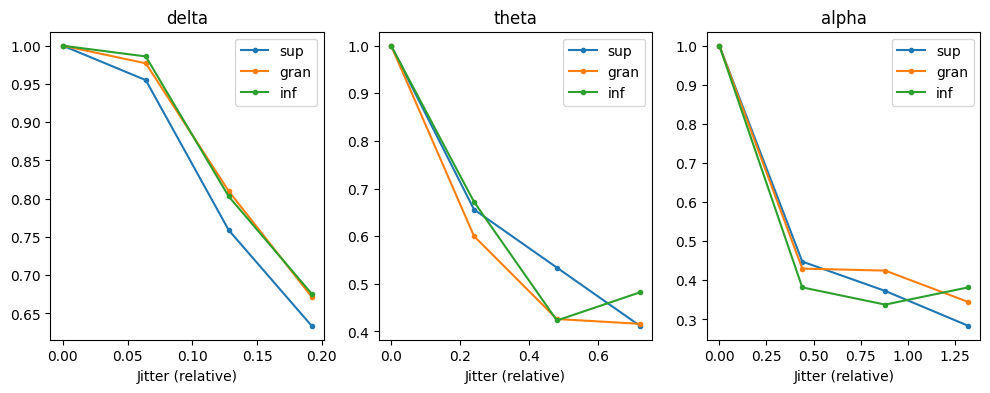

In [20]:
freqs = {'delta': 1.6, 'theta': 6, 'alpha': 11}
chans = ['sup', 'gran', 'inf']

plt.figure(figsize=(12, 4))
for n, (f_name, f) in enumerate(freqs.items()):
    plt.subplot(1, 3, n + 1)
    for ch in chans:
        y = df[f'{f_name}_{ch}']
        plt.plot(jit * f, y.to_numpy(), '.-', label=ch)
    plt.xlabel('Jitter (relative)')
    plt.legend()
    plt.title(f_name)


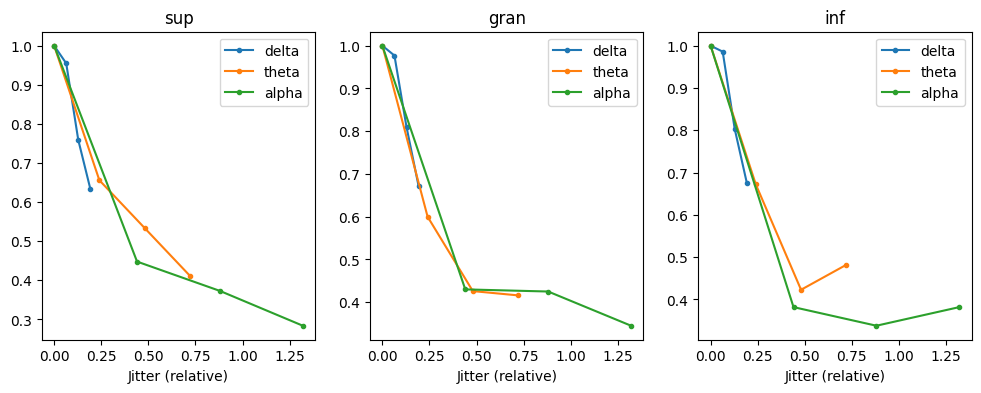

In [23]:
freqs = {'delta': 1.6, 'theta': 6, 'alpha': 11}
chans = ['sup', 'gran', 'inf']

plt.figure(figsize=(12, 4))
for n, ch in enumerate(chans):
    plt.subplot(1, 3, n + 1)
    for f_name, f in freqs.items(): 
        y = df[f'{f_name}_{ch}']
        plt.plot(jit * f, y.to_numpy(), '.-', label=f_name)
    plt.xlabel('Jitter (relative)')
    plt.legend()
    plt.title(ch)


In [18]:
from pathlib import Path
import re
import pandas as pd

dirpath_in = Path(r'D:\WORK\Salvador\repo\A1_OUinp\exp_results\batch_i_ougrid_unconn_state1_mech1_nosub_wmult_0.25\exp_ou_nmean_16_nstd_16\run')
pattern = re.compile(r'Total\s+time\s*=\s*([0-9]*\.?[0-9]+)\s*s', re.IGNORECASE)
run_times = {}

for fp in sorted(dirpath_in.glob('*.run')):
    txt = fp.read_text(errors='ignore')
    matches = pattern.findall(txt)
    run_times[fp.name] = float(matches[-1]) if matches else None

# show results as a pandas Series (pandas is already imported)
T = pd.Series(run_times).sort_index().to_numpy()
print(f'Mean: {T.mean()} s')

Mean: 909.5552343749999 s


In [25]:
T.mean() / 60 * 16 * 16 / 60 / 8

8.084935416666665

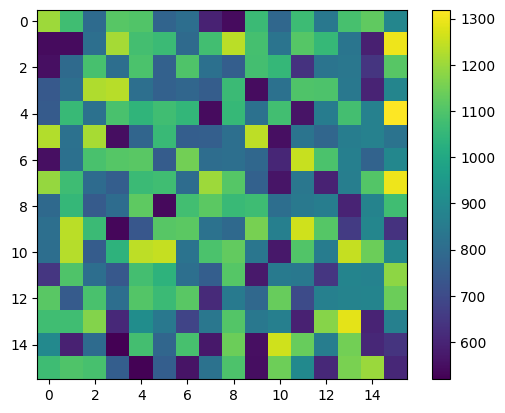

In [22]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(T.reshape((16, 16)))
plt.colorbar()

In [26]:
165500 / 3.4

48676.470588235294